### **Environment Setup & Library Imports**



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install jiwer editdistance evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 88.3 MB/s eta 0:00:00


In [ ]:
import os
import re
import itertools
import numpy as np
import pandas as pd
import torch
import evaluate
import editdistance
from datasets import Dataset, Audio
from dataclasses import dataclass
from typing import Any, Dict, List, Union
from transformers import (
    WhisperForConditionalGeneration,
    WhisperProcessor,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback
)
from jiwer import wer

### **Dataset Preparation & Splitting**

In [ ]:
file_path = "/content/drive/MyDrive/cleaned_ag/ag_data.xlsx"
df = pd.read_excel(file_path)

In [ ]:

def fix_audio_path(old_path):
    if not isinstance(old_path, str):
        return old_path

    filename = os.path.basename(old_path)

    new_base_path = "/content/drive/MyDrive/cleaned_ag/audio/"
    return os.path.join(new_base_path, filename)


df["audio_path"] = df["audio_path"].apply(fix_audio_path)


In [ ]:


df = df.rename(columns={"audio_path": "path", "Northern_aghwarDialect": "text"})
dataset = Dataset.from_pandas(df)
dataset = dataset.cast_column("path", Audio(sampling_rate=16000))

train_testvalid = dataset.train_test_split(test_size=0.3, seed=42)
test_valid = train_testvalid['test'].train_test_split(test_size=0.5, seed=42)

data_splits = {
    'train': train_testvalid['train'],
    'validation': test_valid['train'],
    'test': test_valid['test']
}

In [ ]:
def clean_arabic_text(text):
    if not isinstance(text, str) or not text:
        return ""
    text = re.sub(r'[\u064B-\u0652]', '', text)
    text = re.sub(r'[إأآ]', 'ا', text)
    text = re.sub(r'[^\w\s\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def prepare_example(batch):
    audio_data = batch["path"]
    audio_features = []
    for x in audio_data:
        raw_audio = x["array"]
        feature = processor(raw_audio, sampling_rate=16000).input_features[0]
        audio_features.append(feature)

    text_column = "text"
    cleaned_texts = [clean_arabic_text(t) for t in batch[text_column]]
    text_labels = [
        processor.tokenizer(t).input_ids
        for t in cleaned_texts
    ]

    return {"input_features": audio_features, "labels": text_labels}

save_folder = "/content/drive/MyDrive/pro_data/processed_ag_datasets"
os.makedirs(save_folder, exist_ok=True)

for split in ['train', 'validation', 'test']:
    cols_to_remove = data_splits[split].column_names
    data_splits[split] = data_splits[split].map(
        prepare_example,
        batched=True,
        remove_columns=cols_to_remove,
        batch_size=8
    )

    split_save_path = os.path.join(save_folder, split)

    print(f"{split} ")
    data_splits[split].save_to_disk(split_save_path)

    print(f"{split_save_path}\n")


'save_folder = "/content/drive/MyDrive/pro_data/processed_ag_datasets"\nos.makedirs(save_folder, exist_ok=True)\n\n# تطبيق المعالجة على كافة الانقسامات (Splits)\n# تطبيق المعالجة على كافة الانقسامات (Splits)\nfor split in [\'train\', \'validation\', \'test\']:\n    cols_to_remove = data_splits[split].column_names\n    data_splits[split] = data_splits[split].map(\n        prepare_example,\n        batched=True,\n        remove_columns=cols_to_remove,\n        batch_size=8\n    )\n\n    split_save_path = os.path.join(save_folder, split)\n\n    # 3. الحفظ الآمن على الدرايف باستخدام save_to_disk\n    print(f"💾 {split} ")\n    data_splits[split].save_to_disk(split_save_path)\n\n    print(f"✅{split_save_path}\n")'

In [ ]:
from datasets import load_from_disk
import os

save_folder =  "/content/drive/MyDrive/pro_data/processed_ag_datasetsss"

train_dataset = load_from_disk(os.path.join(save_folder, 'train'))
val_dataset   = load_from_disk(os.path.join(save_folder, 'validation'))
test_dataset  = load_from_disk(os.path.join(save_folder, 'test'))

print(train_dataset)

Dataset({
    features: ['input_features', 'labels'],
    num_rows: 1050
})


In [ ]:
@dataclass
class DataCollatorWithPadding:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_features": feature["input_features"]} for feature in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        if batch["input_features"].ndim == 4:
            batch["input_features"] = batch["input_features"].squeeze(1)

        label_features = [{"input_ids": feature["labels"]} for feature in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")


        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)
        batch["labels"] = labels

        return batch

data_collator = DataCollatorWithPadding(processor=processor)

### **Model Configuration & Processor Setup**

In [ ]:
model_name = "openai/whisper-large"

processor = WhisperProcessor.from_pretrained(model_name, language="arabic", task="transcribe")
forced_decoder_ids = processor.get_decoder_prompt_ids(language="arabic", task="transcribe")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    labels = np.where(labels != -100, labels, processor.tokenizer.pad_token_id)
    pred_str = processor.tokenizer.batch_decode(predictions, skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(labels, skip_special_tokens=True)

    wer_score = wer_metric.compute(predictions=pred_str, references=label_str)
    cer_score = cer_metric.compute(predictions=pred_str, references=label_str)

    return {"wer": wer_score * 100, "cer": cer_score * 100}

### **Hyperparameter Tuning Loop (Grid Search)**

In [ ]:
num_epochs = 5
learning_rates = [1e-5]
batch_sizes = [8,4]
optimizers = ["adamw_torch"]

best_wer = float("inf")
best_config = None

for lr, bs, opt in itertools.product(learning_rates, batch_sizes, optimizers):
    print(f"\n=====   LR={lr}, Batch={bs}, Optimizer={opt} =====")

    grad_accum = 2 if bs < 16 else 1
    model = WhisperForConditionalGeneration.from_pretrained(model_name)

    model.config.use_cache = False

    model.generation_config.forced_decoder_ids = forced_decoder_ids
    model.generation_config.suppress_tokens = []

    training_args = Seq2SeqTrainingArguments(
        output_dir="./whisper_ag_tuning",
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=max(1, bs // 2),
        gradient_accumulation_steps=grad_accum,
        eval_strategy="steps",
        num_train_epochs=num_epochs,
        save_steps=100,
        save_total_limit=1,
        logging_steps=50,
        learning_rate=lr,
        fp16=torch.cuda.is_available(),
        optim=opt,
        report_to="none",
        predict_with_generate=True,
        generation_max_length=225,
        load_best_model_at_end=True,
        metric_for_best_model="wer",
        greater_is_better=False,
        save_strategy="steps",
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()

    metrics = trainer.evaluate()
    val_wer = metrics.get("eval_wer", float("inf"))
    val_loss = metrics.get("eval_loss", float("inf"))
    print(f"   Validation Loss: {val_loss:.4f} | Validation WER: {val_wer:.2f}%")
    if val_wer < best_wer:
        best_wer = val_wer
        best_config = (lr, bs, opt)
        trainer.save_model("./best_whisperlarge_ag_1e_8_adam")
        processor.save_pretrained("./best_whisperlarge_ag_1e_8_adam")

print("\n Hyperparameters ")
print(f"Learning Rate: {best_config[0]} | Batch Size: {best_config[1]} | Optimizer: {best_config[2]}")
print(f"Best Validation WER: {best_wer:.2f}%")


=====   LR=1e-05, Batch=8, Optimizer=adamw_torch =====


Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

Step,Training Loss,Validation Loss,Wer,Cer
50,1.428033,0.214038,19.061802,8.270221
100,0.232184,0.206375,16.827997,7.573463
150,0.119372,0.215902,15.785555,4.165404
200,0.056976,0.207065,14.892033,3.862466
250,0.026592,0.214824,15.711095,10.209028
300,0.012894,0.214666,15.487714,10.087852


Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Step,Training Loss,Validation Loss,Wer,Cer
50,1.648832,0.325399,22.114669,5.892154
100,0.543268,0.218139,54.877141,66.298091
150,0.313909,0.212081,19.731943,11.844895


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Step,Training Loss,Validation Loss,Wer,Cer
50,1.648832,0.325399,22.114669,5.892154
100,0.543268,0.218139,54.877141,66.298091
150,0.313909,0.212081,19.731943,11.844895
200,0.150905,0.203359,60.312733,66.040594
250,0.149697,0.215343,155.100521,191.608603


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

-> تم الانتهاء من هذه التجربة.
   Validation Loss: 0.2153 | Validation WER: 155.10%

✅ Hyperparameters 
Learning Rate: 1e-05 | Batch Size: 8 | Optimizer: adamw_torch
Best Validation WER: 14.89%


In [ ]:
print("\n(Test Set)...")

device = "cuda" if torch.cuda.is_available() else "cpu"
model_path = "./best_whisperlarge_ag_1e_8_adam"
best_model = WhisperForConditionalGeneration.from_pretrained(model_path).to(device)
best_processor = WhisperProcessor.from_pretrained(model_path)

best_model.eval()
test_dataset = test_dataset

predictions = []

for sample in test_dataset:
    inputs = torch.tensor(sample["input_features"]).unsqueeze(0).to(device)

    with torch.no_grad():

        predicted_ids = best_model.generate(
            inputs,
            language="arabic",
            task="transcribe"
        )

    transcription = best_processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]
    reference = best_processor.tokenizer.decode(sample["labels"], skip_special_tokens=True)

    predictions.append({
        "reference": clean_arabic_text(reference),
        "prediction": clean_arabic_text(transcription)
    })


final_references = [p["reference"] for p in predictions]
final_hypotheses = [p["prediction"] for p in predictions]

test_wer_score = wer(final_references, final_hypotheses)
total_cer = sum(editdistance.eval(r, h) for r, h in zip(final_references, final_hypotheses))
total_chars = sum(len(r) for r in final_references) if sum(len(r) for r in final_references) > 0 else 1
test_cer_score = total_cer / total_chars

print(f"\n ")
print(f" WER على Test set: {test_wer_score * 100:.2f}%")
print(f" CER على Test set: {test_cer_score * 100:.2f}%")


pd.DataFrame(predictions).to_csv("whisper_large_ag_1e_8_adam_test_results.csv", index=False)
print(" whisper_large_ag_1e_8_adam_test_results.csv")


(Test Set)...


Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]


 
 WER على Test set: 15.60%
 CER على Test set: 4.09%
✅ whisper_large_ag_1e_8_adam_test_results.csv


### **Zero-Shot Baseline Evaluation (Pre-training)**

In [ ]:
from transformers import WhisperForConditionalGeneration, WhisperProcessor
import torch
import pandas as pd
import soundfile as sf


model_name = "openai/whisper-large"
model = WhisperForConditionalGeneration.from_pretrained(model_name)
processor = WhisperProcessor.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

import pandas as pd
file_path = "/content/drive/MyDrive/cleaned_ag/ag_data.xlsx"
df = pd.read_excel(file_path)

def fix_audio_path(old_path):
    if not isinstance(old_path, str):
        return old_path
    filename = os.path.basename(old_path)
    new_base_path = "/content/drive/MyDrive/cleaned_ag/audio/"
    return os.path.join(new_base_path, filename)

df["audio_path"] = df["audio_path"].apply(fix_audio_path)

results = []

for idx, row in df.iterrows():
    audio_file = row["audio_path"]
    reference_text = row["Northern_aghwarDialect"]

    audio_array, sr = sf.read(audio_file)
    inputs = processor(audio_array, sampling_rate=16000, return_tensors="pt").input_features.to(device)
    with torch.no_grad():
        predicted_ids = model.generate(inputs)

    transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]

    results.append({
        "audio_file": audio_file,
        "reference": reference_text,
        "prediction": transcription
    })

pd.DataFrame(results).to_csv("whisper_large_without_training_results.csv", index=False)
print("✅whisper_large_without_training_results.csv")

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.


✅whisper_med_without_training_results.csv


In [ ]:

results_df = pd.read_csv("whisper_large_without_training_results.csv")

references = results_df["reference"].tolist()
predictions = results_df["prediction"].tolist()


wer_score = wer(references, predictions)


total_cer = sum(editdistance.eval(r, p) for r, p in zip(references, predictions))
total_chars = sum(len(r) for r in references)
cer_score = total_cer / total_chars

print(f"📊 Word Error Rate (WER): {wer_score:.4f}")
print(f"📊 Character Error Rate (CER): {cer_score:.4f}")

📊 Word Error Rate (WER): 0.5767
📊 Character Error Rate (CER): 0.2587


### **Performance Comparison (Before vs. After Fine-Tuning)**

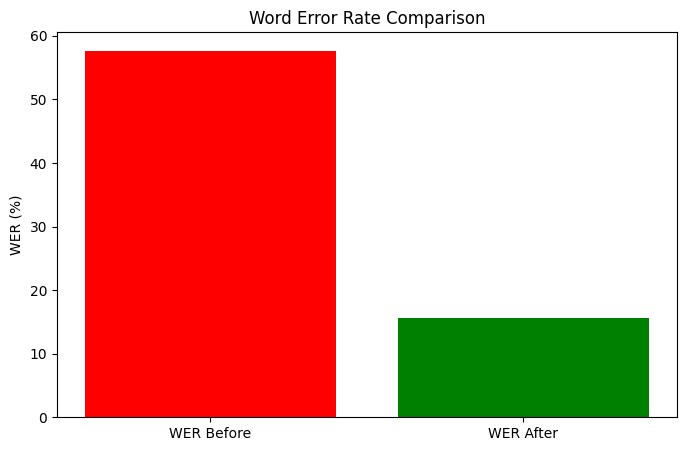

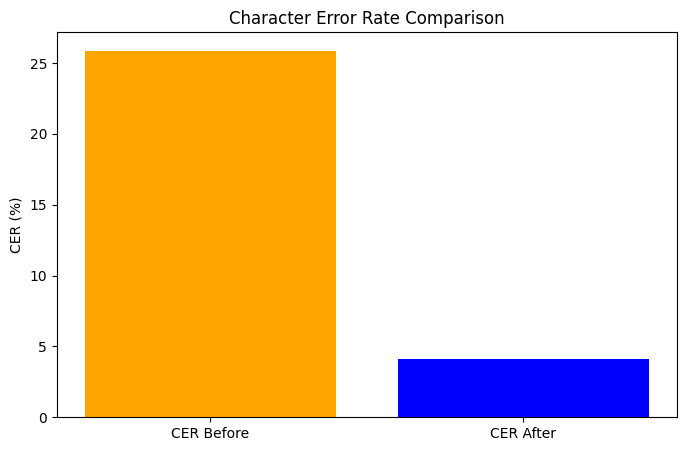

In [ ]:


before_df = pd.read_csv("whisper_large_without_training_results.csv")
after_df = pd.read_csv("whisper_large_ag_1e_8_adam_test_results.csv")

def compute_metrics(df):
    refs = df["reference"].tolist()
    preds = df["prediction"].tolist()
    wer_score = wer(refs, preds)
    total_cer = sum(editdistance.eval(r, p) for r, p in zip(refs, preds))
    total_chars = sum(len(r) for r in refs)
    cer_score = total_cer / total_chars
    return wer_score*100, cer_score*100

wer_before, cer_before = compute_metrics(before_df)
wer_after, cer_after = compute_metrics(after_df)

plt.figure(figsize=(8,5))
plt.bar(["WER Before","WER After"], [wer_before, wer_after], color=["red","green"])
plt.title("Word Error Rate Comparison")
plt.ylabel("WER (%)")
plt.show()

plt.figure(figsize=(8,5))
plt.bar(["CER Before","CER After"], [cer_before, cer_after], color=["orange","blue"])
plt.title("Character Error Rate Comparison")
plt.ylabel("CER (%)")
plt.show()